# End-to-End KNN Classification Framework
This notebook demonstrates a robust KNN pipeline using the Iris dataset, featuring noise simulation, PCA, and hyperparameter optimization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Set plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 300

## Data Loading and Noise Injection
We load the Iris dataset and add Gaussian noise to the features to simulate real-world data complexity and class overlap.

In [2]:
# Load Iris dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

# Inject Gaussian noise (mean=0, std=0.5)
np.random.seed(42)
noise = np.random.normal(0, 0.5, X.shape)
X_noisy = X + noise

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_noisy)

print(f"Data shape after noise injection: {X_scaled.shape}")

Data shape after noise injection: (150, 4)


## Dimensionality Reduction
We use PCA to project the 4-dimensional feature space into a 2D manifold for visualization and potentially simplified classification.

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

Explained variance ratio: [0.61839669 0.23847095]


## Hyperparameter Optimization
We perform a grid search using Stratified Cross-Validation to optimize the KNN model.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.3, stratify=y, random_state=42)

param_grid = {
    'n_neighbors': np.arange(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(knn, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

Best Parameters: {'metric': 'euclidean', 'n_neighbors': np.int64(26), 'weights': 'uniform'}
Best Cross-Validation Score: 0.8571


## Model Evaluation and Visualization
We evaluate the model on the test set and visualize the decision boundaries.

Classification Report:
              precision    recall  f1-score   support

      setosa       0.94      1.00      0.97        15
  versicolor       0.71      0.80      0.75        15
   virginica       0.83      0.67      0.74        15

    accuracy                           0.82        45
   macro avg       0.83      0.82      0.82        45
weighted avg       0.83      0.82      0.82        45



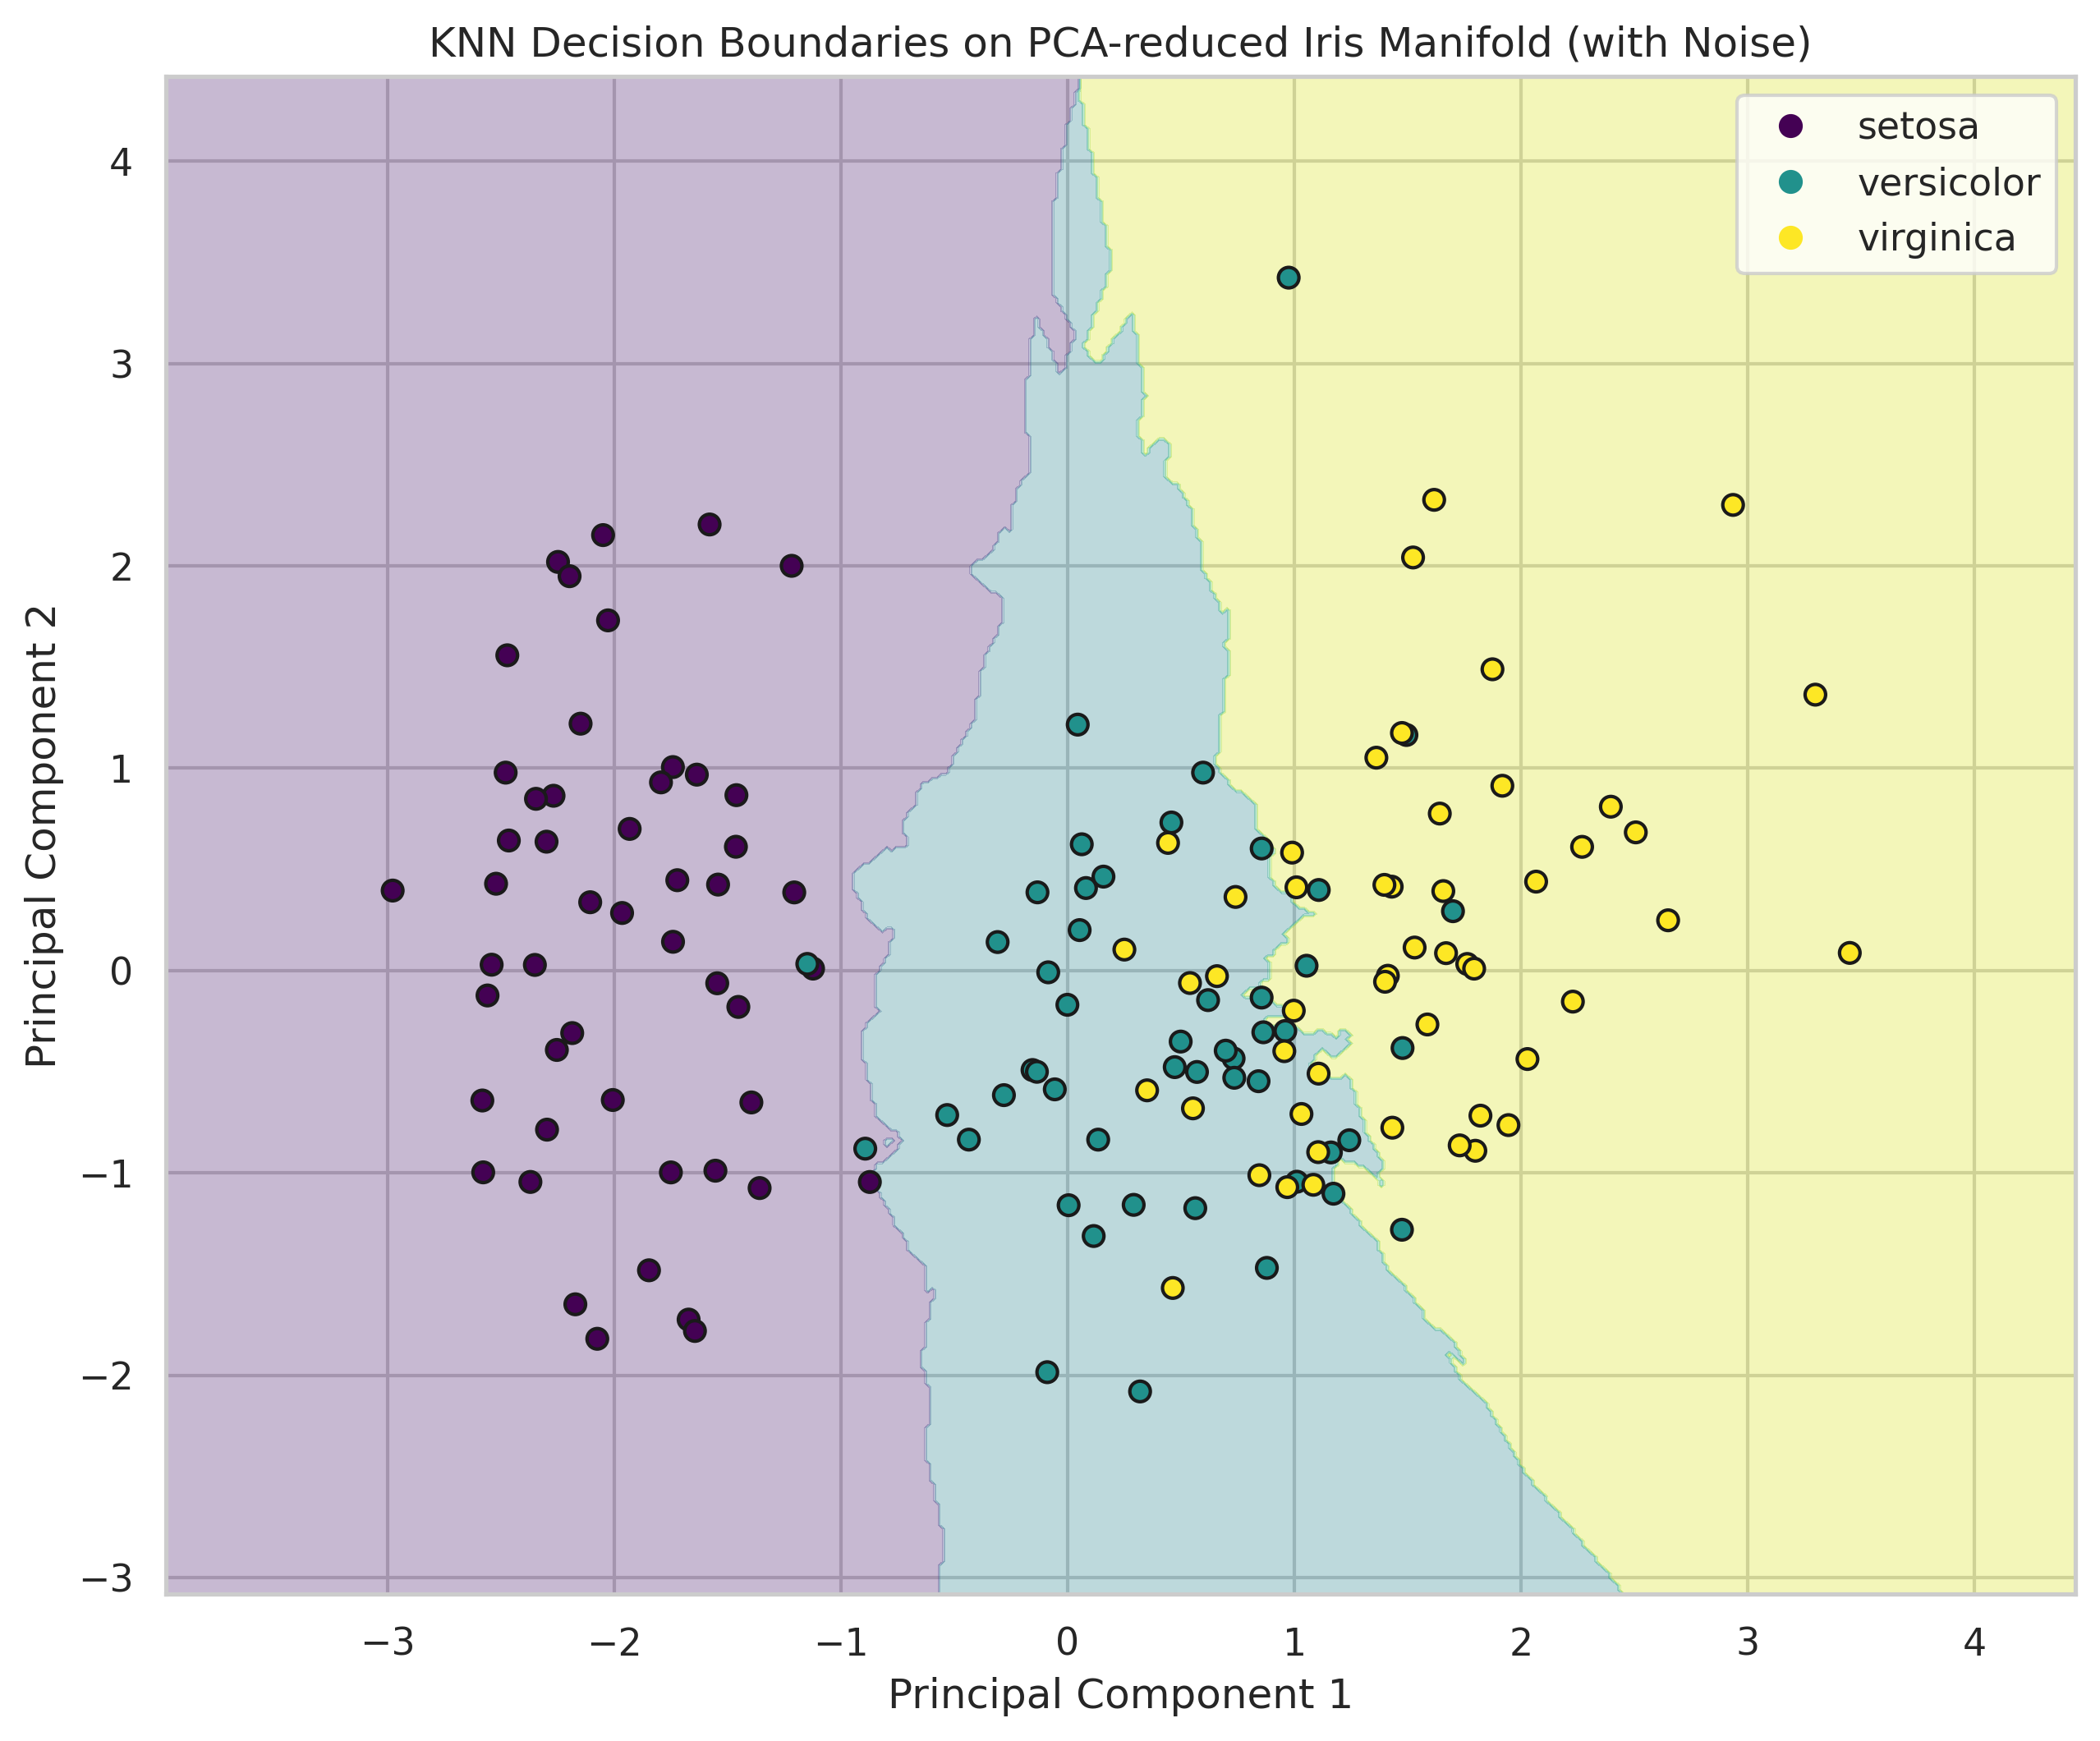

In [5]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Visualization of Decision Boundaries
h = .02  # step size in the mesh
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', cmap='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('KNN Decision Boundaries on PCA-reduced Iris Manifold (with Noise)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(iris.target_names))
plt.show()